In [69]:
import yaml

def read_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
from decimal import Decimal

import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table
from gammapy.data import Observation, Observations, observatory_locations, EventList
from gammapy.datasets import MapDataset, MapDatasetEventSampler, FluxPointsDataset
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, ExcessMapEstimator
from gammapy.estimators import FluxPointsEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, RingBackgroundMaker, SafeMaskMaker
from gammapy.datasets import MapDataset, MapDatasetOnOff
from gammapy.makers import MapDatasetMaker, WobbleRegionsFinder
from gammapy.maps import MapAxis, RegionNDMap, WcsGeom, Map, TimeMapAxis
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ConstantSpectralModel,
    FoVBackgroundModel,
    LightCurveTemplateTemporalModel,
    Models,
    PointSpatialModel,
    PowerLawSpectralModel,
    LogParabolaSpectralModel,
    SkyModel,
)
from regions import PointSkyRegion, CircleSkyRegion

from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    FoVBackgroundMaker
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    SkyModel,
    create_crab_spectral_model,
    PiecewiseNormSpectralModel,
    PowerLawNormSpectralModel,
    LogParabolaSpectralModel,
)

from gammapy.visualization import plot_spectrum_datasets_off_regions

import warnings

ModuleNotFoundError: No module named 'gammapy'

## Read the parfile

In [ ]:
parfile = "./ASTRI_quicklook_analysis_parfile.yaml"
global_parameters = read_yaml(parfile)

## Make the output dir

In [ ]:
output_dir = global_parameters['OUTPUT_RESULTS']['output_dir']
output_dir_notebook = global_parameters['OUTPUT_RESULTS']['1d_spec_analysis_output_dir']
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir).joinpath(output_dir_notebook).mkdir(parents=True, exist_ok=True)

## Load the ASTRI data

In [ ]:
import glob, os, pathlib, itertools

target_name = global_parameters["TARGET"]["target_name"]

input_filenames = []
for folder in global_parameters['INPUT_DATA']['input_EVT3']:
    input_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0201_*.fits.gz')))
input_filenames = tuple(itertools.chain.from_iterable(input_filenames))

irf_filenames = []
for folder in global_parameters['INPUT_DATA']['input_IRF3']:
    irf_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0502_*.fits.gz')))
irf_filenames = tuple(itertools.chain.from_iterable(irf_filenames))

print(f"The number of runs is {len(input_filenames)}; the number of IRF is {len(irf_filenames)}.")
if len(input_filenames) != len(irf_filenames):
    warnings.warn("The number of runs is not compatible with the available IRFs! PLEASE CHECK!")
else:
    print("Run and abailable IRFs are compatible!")

datastore = DataStore.from_events_files(np.sort(input_filenames), irfs_paths=np.sort(irf_filenames))
datastore.hdu_table.write("hdu-index.fits.gz", overwrite=True)
datastore.obs_table.write("obs-index.fits.gz", overwrite=True)

In [ ]:
telescope_name = global_parameters["DATA_ORIGIN"]["telescope"]
target_name = global_parameters["TARGET"]["target_name"]

obs_date = datastore.obs_table[0]["EVENTS_FILENAME"].split("/")[-1][0:8]

In [ ]:
import json

with open(f'{output_dir}/{output_dir_notebook}/1D_spectral_analysis_parfile_summary_{obs_date}_{telescope_name}_{target_name}.txt', 'w') as file:
    file.write(json.dumps(global_parameters))

## Create AZ/ZD columns in the datastore for each run

In [ ]:
ev_header = Table.read(datastore.obs_table["EVENTS_FILENAME"][0], hdu=1)
meta = ev_header.meta
loc = EarthLocation(
            lat=global_parameters['DATA_ORIGIN']['latitude'],
            lon=global_parameters['DATA_ORIGIN']['longitude'],
            # height = (row["TELZ"] + OBSLEV)*u.m
        )

mjdtime = ( ((datastore.obs_table["TSTART"] + datastore.obs_table["TSTOP"])/2).to("d") 
           + (datastore.obs_table["MJDREFI"] + datastore.obs_table["MJDREFF"]) * u.d )
observing_time = Time(mjdtime, format="mjd", scale="tt")  

altazframe = AltAz(location=loc, obstime=observing_time)
datastore.obs_table["DATE-OBS"] = observing_time.isot 
coord = SkyCoord(datastore.obs_table["RA_PNT"], datastore.obs_table["DEC_PNT"], unit="deg", frame="icrs")
coord_altaz = coord.transform_to(altazframe)

datastore.obs_table["AZ_PNT"] = coord_altaz.az.deg * u.deg
datastore.obs_table["ZD_PNT"] = coord_altaz.zen.deg * u.deg

## Select runs according to selection criteria

In [ ]:
target_position = SkyCoord(ra=global_parameters['TARGET']['coord1'], 
                           dec=global_parameters['TARGET']['coord2'], 
                           unit="deg", 
                           frame=global_parameters['TARGET']['frame'])

selection_offset = dict(type='sky_circle',
                lon=target_position.ra.deg,
                lat=target_position.dec.deg,
                frame="icrs",
                radius=Angle(global_parameters['RUN_SELECTION']['offset_max'], 'deg')
                )

value_range_zen = Angle([global_parameters['RUN_SELECTION']['zenith_min'], 
                         global_parameters['RUN_SELECTION']['zenith_max']], 'deg')

selection_zen = dict(type='par_box', variable='ZD_PNT', value_range=value_range_zen)

value_range_az = Angle([global_parameters['RUN_SELECTION']['azimuth_min'], 
                     global_parameters['RUN_SELECTION']['azimuth_max']], 'deg')

selection_az = dict(type='par_box', variable='AZ_PNT', value_range=value_range_az)

value_range_time = np.array([global_parameters['RUN_SELECTION']['tstart'],
                             global_parameters['RUN_SELECTION']['tstop']], float) * u.s
selection_time = dict(type='par_box', variable='TSTART', value_range=value_range_time)

select_obs = datastore.obs_table.select_observations([selection_offset, selection_zen, selection_az, selection_time])
selected_obsid = select_obs["OBS_ID"]

In [ ]:
print(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n")
print(f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n")
print(f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']} \n")

In [ ]:
file_path = Path(f"{output_dir}/{output_dir_notebook}/1D_scientific_analysis_summary_table_{obs_date}_{telescope_name}_{target_name}.txt")
with file_path.open('w') as file:
    file.write(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n\n" +
               f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n\n" +
               f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']}"
              )

## Load the observations

In [ ]:
observations = datastore.get_observations(obs_id=selected_obsid)

## 1D Spectral analysis: reflected regions

In [ ]:
width = global_parameters['DATASET_SETTINGS']['width']
binsz = global_parameters['DATASET_SETTINGS']['binsz']
radius= np.sqrt(global_parameters['DATASET_SETTINGS']['on_radius'])

on_region_radius = Angle(radius * u.deg)
on_region = CircleSkyRegion(center=target_position, radius=on_region_radius)

npix = int(width/binsz)

exclusion_region = [CircleSkyRegion(
    center=target_position,
    radius=radius * u.deg,
    )]

for i, src in enumerate(global_parameters['EXCLUSION_REGIONS']['source']):
    src_position = SkyCoord(ra=global_parameters['EXCLUSION_REGIONS']['src_coord1'][i], 
                            dec=global_parameters['EXCLUSION_REGIONS']['src_coord2'][i], 
                            unit="deg", 
                            frame=global_parameters['EXCLUSION_REGIONS']['frame'][i])
    
    src_exclusion_region = CircleSkyRegion(
                                    center=src_position,
                                    radius=global_parameters['EXCLUSION_REGIONS']['src_radius'][i] * u.deg,
                                    )
    exclusion_region.append(src_exclusion_region)

geom_excl = WcsGeom.create(
    npix=(npix, npix), binsz=binsz, skydir=target_position.galactic, proj="TAN", frame="galactic"
)

exclusion_mask = ~geom_excl.region_mask(exclusion_region)
exclusion_mask.plot()

plt.savefig(f"{output_dir}/{output_dir_notebook}/Exclusion_mask_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [ ]:
e_min, e_max = (global_parameters['DATASET_SETTINGS']['energy_reco_min'] * u.TeV, 
                global_parameters['DATASET_SETTINGS']['energy_reco_max'] * u.TeV) 

energy_axis = MapAxis.from_energy_bounds(
                    e_min, e_max, 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_reco'], 
                    per_decade=False, unit="TeV", name="energy") 

# Reduced IRFs are defined in true energy (i.e. not measured energy).
energy_axis_true = MapAxis.from_energy_bounds(
                    global_parameters['DATASET_SETTINGS']['energy_true_min'], 
                    global_parameters['DATASET_SETTINGS']['energy_true_max'], 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_true'], 
                    per_decade=False, unit="TeV", name="energy_true" 
                    )

# geometry defining the ON region and SpectrumDataset based on it
geom = RegionGeom.create(region=on_region, axes=[energy_axis])

dataset_empty = SpectrumDataset.create(geom=geom, energy_axis_true=energy_axis_true)

dataset_maker = SpectrumDatasetMaker(
    containment_correction=True, selection=["counts", "exposure", "edisp"]
)

if global_parameters['DATASET_SETTINGS']['full_reflected_regions'] == False:
    # tell the background maker to use the WobbleRegionsFinder, let us use 3 off by default
    region_finder = WobbleRegionsFinder(n_off_regions=3)
    maker_fov = ReflectedRegionsBackgroundMaker(region_finder=region_finder, exclusion_mask=exclusion_mask)
else:
    maker_fov = ReflectedRegionsBackgroundMaker(exclusion_mask=exclusion_mask)

offset_max = global_parameters['SAFEMASK_DATSET']['offset_max'] * u.deg
safe_mask_masker = SafeMaskMaker(
#    methods=["offset-max", "aeff-max"], aeff_percent=5, offset_max=offset_max
    methods=["aeff-default","offset-max"], offset_max=offset_max
 )

In [ ]:
datasets = Datasets()

# create a counts map for visualisation later...
#counts = Map.create(skydir=target_position, width=width)
counts= Map.from_geom(geom_excl)

for observation in observations:
    dataset = dataset_maker.run(
        dataset_empty.copy(name=str(observation.obs_id)), observation
    )
    counts.fill_events(observation.events)
    dataset_on_off = maker_fov.run(dataset, observation)
    dataset_on_off = safe_mask_masker.run(dataset_on_off, observation)
    datasets.append(dataset_on_off)

In [ ]:
#plot
ax = counts.smooth(0.05 * u.deg).plot(stretch="linear", cmap="viridis", add_cbar=True)
geom.plot_region(ax=ax, kwargs_point={"color": "k", "marker": "*"}, color="r", linewidth=2.5)
plot_spectrum_datasets_off_regions(ax=ax, datasets=datasets, linewidth=2.5)

plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_counts_map_reflected_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [ ]:
# Individual
info_table=datasets.info_table()
info_table

In [ ]:
# Cumulative
info_table= datasets.info_table(cumulative=True)
info_table

NameError: name 'info_table' is not defined

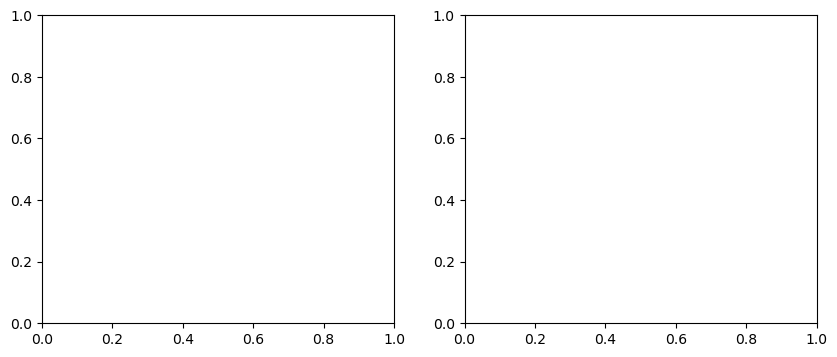

In [2]:
fig, (ax_excess, ax_sqrt_ts) = plt.subplots(figsize=(10, 4), ncols=2, nrows=1)
ax_excess.plot(
    info_table["livetime"].to("h"),
    info_table["excess"],
    marker="o",
    ls="none",
)

ax_excess.set_title("Excess")
ax_excess.set_xlabel("Livetime [h]")
ax_excess.set_ylabel("Excess events")

ax_sqrt_ts.plot(
    info_table["livetime"].to("h"),
    info_table["sqrt_ts"],
    marker="o",
    ls="none",
)

ax_sqrt_ts.set_title("Sqrt(TS)")
ax_sqrt_ts.set_xlabel("Livetime [h]")
ax_sqrt_ts.set_ylabel("Sqrt(TS)")

plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_excess_significance_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_excess_significance_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')

## Run a stacked spectral analysis

In [3]:
dataset_stacked = Datasets(datasets).stack_reduce()

NameError: name 'Datasets' is not defined

In [4]:
if global_parameters['SPECTRAL_MODEL']['model'] == "powerlaw":
    spectral_model = PowerLawSpectralModel(index=global_parameters['SPECTRAL_MODEL']['index'], 
                                           amplitude=global_parameters['SPECTRAL_MODEL']['amplitude'], 
                                           reference=global_parameters['SPECTRAL_MODEL']['reference'])
if global_parameters['SPECTRAL_MODEL']['model'] == "logparabola":
    spectral_model = LogParabolaSpectralModel.from_log10(alpha=global_parameters['SPECTRAL_MODEL']['alpha'], 
                                              beta=global_parameters['SPECTRAL_MODEL']['beta'], 
                                              amplitude=global_parameters['SPECTRAL_MODEL']['amplitude'], 
                                              reference=global_parameters['SPECTRAL_MODEL']['reference'])
    #spectral_model.parameters["alpha"].frozen = True
    spectral_model.parameters["beta"].frozen = True

model = SkyModel(spectral_model=spectral_model, name=global_parameters['TARGET']['target_name'])
dataset_stacked.models = model
dataset_stacked.models[0].spectral_model.amplitude.min = 0

dataset_stacked.mask_fit = dataset_stacked.counts.geom.energy_mask(
    energy_min=global_parameters['SPECTRAL_FIT']['energy_min'] * u.TeV, energy_max=global_parameters['SPECTRAL_FIT']['energy_max']*u.TeV
)

NameError: name 'global_parameters' is not defined

In [5]:
fit = Fit()
result_stacked = fit.run(dataset_stacked)

print(result_stacked)

# we make a copy here to compare it later
best_fit_model = datasets.models.copy()

NameError: name 'Fit' is not defined

In [6]:
dataset_stacked.models.parameters.to_table()

NameError: name 'dataset_stacked' is not defined

In [7]:
# write best fit
dataset_stacked.models.parameters.to_table().write(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_best_fit_model_{obs_date}_{telescope_name}_{target_name}.txt", format="ascii", overwrite=True)

NameError: name 'dataset_stacked' is not defined

In [8]:
print(f"Best-fit statistics: {dataset_stacked.stat_sum()}")

NameError: name 'dataset_stacked' is not defined

## Extract spectral points

In [9]:
energy_edges = energy_axis.downsample(global_parameters['SPECTRAL_POINTS']['downsample']).edges 

fpe = FluxPointsEstimator(
    energy_edges=energy_edges, 
    source=global_parameters['TARGET']['target_name'], 
    selection_optional="all", 
    n_sigma=global_parameters['SPECTRAL_POINTS']['n_sigma'], 
    n_sigma_ul=global_parameters['SPECTRAL_POINTS']['n_sigma_ul'], 
    n_jobs=7
)

flux_points = fpe.run(datasets=dataset_stacked)
flux_points.sqrt_ts_threshold_ul = global_parameters['SPECTRAL_POINTS']['sqrt_ts_threshold_ul'] # in units of sqrt(TS)

NameError: name 'energy_axis' is not defined

In [10]:
flux_points.to_table()

NameError: name 'flux_points' is not defined

NameError: name 'global_parameters' is not defined

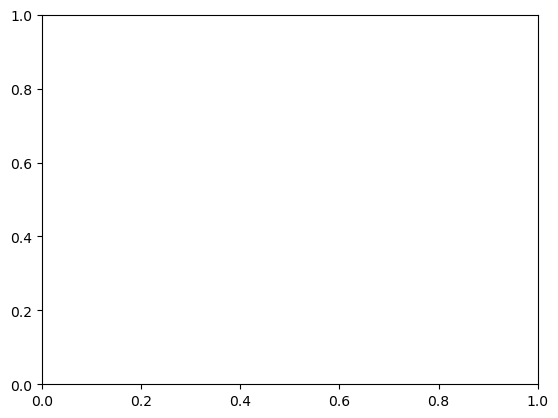

In [11]:
fig, ax = plt.subplots()
sed_type = global_parameters['SPECTRAL_POINTS']['sed_type']
flux_points.plot(ax=ax, sed_type=sed_type, color="darkorange")
flux_points.plot_ts_profiles(ax=ax, sed_type=sed_type)
model.spectral_model.plot(ax=ax, energy_bounds=(e_min, e_max), sed_type=sed_type)
model.spectral_model.plot_error(ax=ax, energy_bounds=(e_min, e_max), sed_type=sed_type)
plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_spectrum_fitstatistics_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [12]:
if global_parameters['SPECTRAL_MODEL_TO_COMPARE']['model'] == "powerlaw":
    model_source = PowerLawSpectralModel(index=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['index'], 
                                           amplitude=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['amplitude'], 
                                           reference=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['reference'])
if global_parameters['SPECTRAL_MODEL_TO_COMPARE']['model'] == "logparabola":
    model_source = LogParabolaSpectralModel.from_log10(alpha=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['alpha'], 
                                              beta=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['beta'], 
                                              amplitude=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['amplitude'], 
                                              reference=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['reference'])
model_name = global_parameters['SPECTRAL_MODEL_TO_COMPARE']['name']

NameError: name 'global_parameters' is not defined

In [13]:
if global_parameters['SPECTRAL_MODEL']['model'] == "powerlaw":
    best_fit_label = (f"Best-fit {global_parameters['SPECTRAL_MODEL']['model']} model: \n" + 
                      r"$\Gamma$ = " + f"{'{:.2f}'.format(dataset_stacked.models.parameters['index'].value)}" +
                      f"+/- {'{:.2f}'.format(dataset_stacked.models.parameters['index'].error)},\n" + 
                      f"Norm = {'{:.2E}'.format(Decimal(dataset_stacked.models.parameters['amplitude'].value))}" + 
                      f"+/- {'{:.2E}'.format(Decimal(dataset_stacked.models.parameters['amplitude'].error))} {dataset_stacked.models.parameters['amplitude'].unit},\n"
                      f"reference = {'{:.2f}'.format(dataset_stacked.models.parameters['reference'].value)} {dataset_stacked.models.parameters['reference'].unit} \n" 
                      )
if global_parameters['SPECTRAL_MODEL']['model'] == "logparabola":
    best_fit_label = (f"Best-fit {global_parameters['SPECTRAL_MODEL']['model']} model: \n" + 
                      r"$\alpha$ = " + f"{'{:.2f}'.format(dataset_stacked.models.parameters['alpha'].value)}" +
                      f"+/- {'{:.2f}'.format(dataset_stacked.models.parameters['alpha'].error)},\n" +
                      r"$\beta$ = " + f"{'{:.2f}'.format(dataset_stacked.models.parameters['beta'].value)}" +
                      f"+/- {'{:.2f}'.format(dataset_stacked.models.parameters['beta'].error)},\n" + 
                      f"Norm = {'{:.2E}'.format(Decimal(dataset_stacked.models.parameters['amplitude'].value))}" + 
                      f"+/- {'{:.2E}'.format(Decimal(dataset_stacked.models.parameters['amplitude'].error))} {dataset_stacked.models.parameters['amplitude'].unit},\n"
                      f"reference = {'{:.2f}'.format(dataset_stacked.models.parameters['reference'].value)} {dataset_stacked.models.parameters['reference'].unit} \n" 
                      )

NameError: name 'global_parameters' is not defined

NameError: name 'global_parameters' is not defined

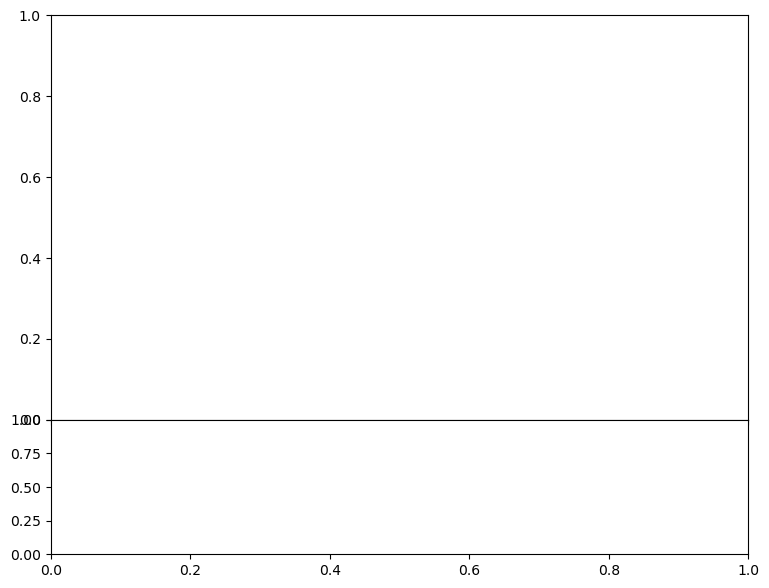

In [14]:
fig, ax = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(9, 7), 
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
sed_type=global_parameters['SPECTRAL_POINTS']['sed_type']
flux_points.plot(ax=ax[0], sed_type=sed_type, color="red", label = f"Data points ({np.round(dataset_stacked.gti.time_sum.to("hr"),1)})")

edge_bin_low = energy_edges[(energy_edges.value < global_parameters['SPECTRAL_FIT']['energy_min'])][-1] 
edge_bin_high = energy_edges[(energy_edges.value > global_parameters['SPECTRAL_FIT']['energy_max'])][0] 

model.spectral_model.plot(ax=ax[0], energy_bounds=(edge_bin_low, edge_bin_high), sed_type=sed_type, color="green", label=best_fit_label)
model.spectral_model.plot_error(ax=ax[0], energy_bounds=(edge_bin_low, edge_bin_high), sed_type=sed_type, facecolor="green")
#e_min_fit, e_max_fit = (global_parameters['SPECTRAL_FIT']['energy_min'] * u.TeV, 
#                global_parameters['SPECTRAL_FIT']['energy_max'] * u.TeV)
#model.spectral_model.plot(ax=ax, energy_bounds=(e_min_fit, e_max_fit), sed_type=sed_type, color="green", label=best_fit_label)
#model.spectral_model.plot_error(ax=ax, energy_bounds=(e_min_fit, e_max_fit), sed_type=sed_type, facecolor="green")

model_source.plot(ax=ax[0], energy_bounds=(edge_bin_low, edge_bin_high), sed_type=sed_type, color="blue", label=model_name, linestyle='--')
model_source.plot_error(ax=ax[0], energy_bounds=(edge_bin_low, edge_bin_high), sed_type=sed_type, facecolor="blue")
ax[0].legend(loc=3, prop={'size': 8})

if global_parameters['SPECTRUM_PLOTTING_SETTINGS']['x_min'] is not None:
    x_min, x_max = (float(global_parameters['SPECTRUM_PLOTTING_SETTINGS']['x_min']), 
                    float(global_parameters['SPECTRUM_PLOTTING_SETTINGS']['x_max']) )
else:
    x_min, x_max = edge_bin_low, edge_bin_high
ax[0].set_xlim(x_min, x_max)

if global_parameters['SPECTRUM_PLOTTING_SETTINGS']['y_min'] is not None:
    y_min, y_max = (float(global_parameters['SPECTRUM_PLOTTING_SETTINGS']['y_min']), 
                    float(global_parameters['SPECTRUM_PLOTTING_SETTINGS']['y_max']) )
    ax[0].set_ylim(y_min, y_max)

fp_dataset = FluxPointsDataset(data=flux_points, models=model)

# Puoi scegliere method="diff" (assoluti), "diff/model" (relativi), o "diff/sqrt(model)" (residui sigma)
# Per le SED, "diff/model" è spesso il più utile.
fp_dataset.plot_residuals(
    ax=ax[1], 
    method="diff/model", 
    color="black"
)

# Cosmetica per i residui
ax[1].set_ylabel("Diff / Model")
#ax[1].grid(which="both", alpha=0.5)
ax[1].axhline(0, color="gray", lw=1, linestyle="--")
ax[1].set_ylim(-2,2)

for axis in ax:
    axis.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Specifico per il pannello sopra: assicurati che le tacche in basso siano visibili
ax[0].tick_params(axis='x', bottom=True, labelbottom=False)

legend = ax[1].legend()
legend.remove()

ax[0].legend()
plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_best_spectrum_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/1D_spectral_analysis_best_spectrum_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')